On utilise la fonction sigmoïde car on cherche à résoudre un problème de **classification binaire**.

Le neurone calcule d’abord une combinaison linéaire des variables d’entrée :
$$
z = w_1 x_1 + w_2 x_2 + b.
$$

Cependant, $z$ peut prendre n’importe quelle valeur réelle. Il ne peut donc pas être interprété directement comme une probabilité.

On applique alors la fonction sigmoïde :
$$
a = \sigma(z) = \frac{1}{1+e^{-z}},
$$
qui transforme toute valeur réelle $z$ en une valeur comprise entre $0$ et $1$ :
$$
0 < a < 1.
$$

Cette transformation est utile pour plusieurs raisons :

- elle permet d’interpréter la sortie $a$ comme une probabilité d’appartenir à la classe $1$ :
$$
a = \mathbb{P}(y=1 \mid x),
$$

- elle permet de définir une règle de décision simple, par exemple :
$$
\hat y =
\begin{cases}
1 & \text{si } a \geq 0.5, \\
0 & \text{si } a < 0.5,
\end{cases}
$$

- elle est dérivable, ce qui permet d’entraîner le modèle par descente de gradient.

Enfin, la sigmoïde est naturellement adaptée à la fonction de coût utilisée en classification binaire, appelée **log-loss** :
$$
L = -\frac{1}{m}\sum_{i=1}^m \left( y^{(i)} \log(a^{(i)}) + (1-y^{(i)})\log(1-a^{(i)}) \right).
$$

Ainsi, la fonction sigmoïde permet de convertir la sortie linéaire du neurone en une quantité interprétable comme une probabilité, ce qui en fait un choix naturel pour un réseau de neurones de classification binaire.


On considère, pour une observation, la fonction de coût
$$
L(a,y) = -\left(y\log a + (1-y)\log(1-a)\right),
$$
avec
$$
a = \sigma(z) = \frac{1}{1+e^{-z}},
\qquad
z = w_1 x_1 + w_2 x_2 + b.
$$

On cherche à calculer la dérivée partielle de $L$ par rapport à $w_1$.

Par la règle de chaîne,
$$
\frac{\partial L}{\partial w_1}
=
\frac{\partial L}{\partial a}
\cdot
\frac{\partial a}{\partial z}
\cdot
\frac{\partial z}{\partial w_1}.
$$

Calculons chaque terme.

D’abord,
$$
L(a,y) = -y\log a -(1-y)\log(1-a).
$$

Donc
$$
\frac{\partial L}{\partial a}
=
-\frac{y}{a} - (1-y)\frac{-1}{1-a}
=
-\frac{y}{a} + \frac{1-y}{1-a}.
$$

Ensuite, comme
$$
a = \sigma(z) = \frac{1}{1+e^{-z}},
$$
on sait que
$$
\frac{\partial a}{\partial z} = a(1-a).
$$

Enfin,
$$
z = w_1 x_1 + w_2 x_2 + b,
$$
donc
$$
\frac{\partial z}{\partial w_1} = x_1.
$$

En remplaçant dans la règle de chaîne :
$$
\frac{\partial L}{\partial w_1}
=
\left(-\frac{y}{a} + \frac{1-y}{1-a}\right)
a(1-a)\,x_1.
$$

Développons :
$$
\left(-\frac{y}{a} + \frac{1-y}{1-a}\right)a(1-a)
=
-y(1-a) + (1-y)a.
$$

Puis
$$
-y(1-a) + (1-y)a
=
-y + ya + a - ay
=
a-y.
$$

Ainsi,
$$
\frac{\partial L}{\partial w_1} = (a-y)x_1.
$$

On obtient donc le résultat final :
$$
\boxed{\frac{\partial L}{\partial w_1} = (a-y)x_1.}
$$


La règle de chaîne est utilisée parce que $L$ ne dépend pas directement de $w_1$.

En effet, les dépendances sont :
$$
w_1 \longrightarrow z \longrightarrow a \longrightarrow L
$$

car :
$$
z = w_1 x_1 + w_2 x_2 + b,
$$
$$
a = \sigma(z),
$$
$$
L = L(a,y).
$$

Donc lorsque $w_1$ varie :

- $z$ varie,
- puis $a$ varie,
- puis $L$ varie.

La règle de chaîne consiste alors à multiplier les dérivées le long de cette chaîne de dépendance :
$$
\frac{\partial L}{\partial w_1}
=
\frac{\partial L}{\partial a}
\cdot
\frac{\partial a}{\partial z}
\cdot
\frac{\partial z}{\partial w_1}.
$$


## 2. Vectorisation de $Z$

On regroupe les $m$ observations dans la matrice
$$
X =
\begin{pmatrix}
x_1^{(1)} & x_2^{(1)} \\
x_1^{(2)} & x_2^{(2)} \\
\vdots & \vdots \\
x_1^{(m)} & x_2^{(m)}
\end{pmatrix}.
$$

On note également
$$
Z =
\begin{pmatrix}
z^{(1)} \\
z^{(2)} \\
\vdots \\
z^{(m)}
\end{pmatrix}.
$$

Or, pour chaque observation $i$, on a
$$
z^{(i)} = w_1 x_1^{(i)} + w_2 x_2^{(i)} + b.
$$

Ainsi,
$$
Z =
\begin{pmatrix}
w_1 x_1^{(1)} + w_2 x_2^{(1)} + b \\
w_1 x_1^{(2)} + w_2 x_2^{(2)} + b \\
\vdots \\
w_1 x_1^{(m)} + w_2 x_2^{(m)} + b
\end{pmatrix}.
$$

Cette écriture peut se vectoriser sous la forme
$$
Z = XW + B,
$$
où
$$
W =
\begin{pmatrix}
w_1 \\
w_2
\end{pmatrix},
\qquad
B =
\begin{pmatrix}
b \\
b \\
\vdots \\
b
\end{pmatrix}.
$$

Autrement dit,
$$
\begin{pmatrix}
z^{(1)} \\
z^{(2)} \\
\vdots \\
z^{(m)}
\end{pmatrix}
=
\begin{pmatrix}
x_1^{(1)} & x_2^{(1)} \\
x_1^{(2)} & x_2^{(2)} \\
\vdots & \vdots \\
x_1^{(m)} & x_2^{(m)}
\end{pmatrix}
\begin{pmatrix}
w_1 \\
w_2
\end{pmatrix}
+
\begin{pmatrix}
b \\
b \\
\vdots \\
b
\end{pmatrix}.
$$


## 3. Vectorisation de $A$

On note
$$
A =
\begin{pmatrix}
a^{(1)} \\
a^{(2)} \\
\vdots \\
a^{(m)}
\end{pmatrix}.
$$

Pour chaque observation $i$, on a
$$
a^{(i)} = \sigma\left(z^{(i)}\right)
= \frac{1}{1+e^{-z^{(i)}}}.
$$

Ainsi, le vecteur $A$ s’obtient en appliquant la fonction sigmoïde à chaque composante de $Z$ :
$$
A =
\begin{pmatrix}
a^{(1)} \\
a^{(2)} \\
\vdots \\
a^{(m)}
\end{pmatrix}
=
\sigma
\begin{pmatrix}
z^{(1)} \\
z^{(2)} \\
\vdots \\
z^{(m)}
\end{pmatrix}
=
\sigma(Z).
$$

Autrement dit, la fonction sigmoïde est appliquée composante par composante au vecteur $Z$.


## 4. Vectorisation de la fonction coût

On cherche à calculer l’erreur globale en sommant les erreurs entre chaque prédiction $a^{(i)}$ et la vraie valeur $y^{(i)}$.

La fonction coût moyenne s’écrit alors :
$$
\mathcal{L}
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y^{(i)} \log\left(a^{(i)}\right)
+
\left(1-y^{(i)}\right)\log\left(1-a^{(i)}\right)
\right].
$$

Cette expression correspond à la **log-loss** moyenne sur les $m$ observations.


## 4. Vectorisation de la fonction coût

On cherche à calculer l’erreur globale en faisant la somme des erreurs entre chaque prédiction $a^{(i)}$ et chaque valeur réelle $y^{(i)}$.

Notre objectif est donc de comparer directement le vecteur $A$ au vecteur $y$.

La fonction coût s’écrit :
$$
\mathcal{L}
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y^{(i)} \log\left(a^{(i)}\right)
+
\left(1-y^{(i)}\right)\log\left(1-a^{(i)}\right)
\right].
$$

Les termes situés à l’intérieur de la somme peuvent être regroupés sous la forme d’un vecteur de dimension $(m,1)$ :
$$
\begin{pmatrix}
y^{(1)}\log\left(a^{(1)}\right) + \left(1-y^{(1)}\right)\log\left(1-a^{(1)}\right) \\
y^{(2)}\log\left(a^{(2)}\right) + \left(1-y^{(2)}\right)\log\left(1-a^{(2)}\right) \\
\vdots \\
y^{(m)}\log\left(a^{(m)}\right) + \left(1-y^{(m)}\right)\log\left(1-a^{(m)}\right)
\end{pmatrix}.
$$

La fonction coût correspond alors à la moyenne opposée des composantes de ce vecteur.


La somme de ce vecteur donne un nombre réel.

## 5. Vectorisation de la descente de gradient

Les paramètres du modèle sont mis à jour selon les équations :
$$
w_1 \leftarrow w_1 - \alpha \frac{\partial \mathcal{L}}{\partial w_1},
$$

$$
w_2 \leftarrow w_2 - \alpha \frac{\partial \mathcal{L}}{\partial w_2},
$$

$$
b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b},
$$

où $\alpha$ désigne le pas d’apprentissage.

On peut regrouper les poids dans le vecteur
$$
W =
\begin{pmatrix}
w_1 \\
w_2
\end{pmatrix}.
$$

On regroupe les poids dans le vecteur
$$
W =
\begin{pmatrix}
w_1 \\
w_2
\end{pmatrix}.
$$

De même, le gradient de la fonction coût par rapport à $W$ s’écrit
$$
\frac{\partial \mathcal{L}}{\partial W}
=
\begin{pmatrix}
\frac{\partial \mathcal{L}}{\partial w_1} \\
\frac{\partial \mathcal{L}}{\partial w_2}
\end{pmatrix}.
$$

La mise à jour des poids peut alors s’écrire sous forme vectorisée :
$$
W \leftarrow W - \alpha \frac{\partial \mathcal{L}}{\partial W}.
$$

Le biais est mis à jour séparément selon :
$$
b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b}.
$$

Ici, $\dfrac{\partial \mathcal{L}}{\partial W}$ correspond au vecteur des dérivées partielles de $\mathcal{L}$ par rapport aux composantes de $W$.

D’un point de vue mathématique, une écriture plus rigoureuse serait
$$
W_{t+1} = W_t - \alpha \frac{\partial \mathcal{L}}{\partial W_t}.
$$

Cependant, la notation
$$
W \leftarrow W - \alpha \frac{\partial \mathcal{L}}{\partial W}
$$
est plus pratique dans la partie programmation.






Pour une observation, on a
$$
z = w_1x_1 + w_2x_2 + b,
\qquad
a = \sigma(z).
$$

La fonction de coût associée à une observation est
$$
L(a,y) = -\left(y\log a + (1-y)\log(1-a)\right).
$$

On cherche la dérivée de $L$ par rapport à $b$.

Comme $L$ dépend de $b$ par l’intermédiaire de $a$, puis de $z$, on applique la règle de chaîne :
$$
\frac{\partial L}{\partial b}
=
\frac{\partial L}{\partial a}
\cdot
\frac{\partial a}{\partial z}
\cdot
\frac{\partial z}{\partial b}.
$$

Or, on a déjà montré que
$$
\frac{\partial L}{\partial a}
\cdot
\frac{\partial a}{\partial z}
=
a-y.
$$

De plus,
$$
\frac{\partial z}{\partial b} = 1.
$$

Ainsi,
$$
\frac{\partial L}{\partial b}
=
(a-y)\cdot 1
=
a-y.
$$

On obtient donc
$$
\boxed{\frac{\partial L}{\partial b} = a-y.}
$$

Pour la fonction coût moyenne sur les $m$ observations, on a alors
$$
\boxed{
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}\left(a^{(i)}-y^{(i)}\right)
}.
$$


Le biais se met à jour selon la règle :
$$
b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b}.
$$

Rappel : $b$ est un nombre réel, et non un vecteur.

Par conséquent, la dérivée partielle
$$
\frac{\partial \mathcal{L}}{\partial b}
$$
est elle aussi un nombre réel.

Il n’est donc pas nécessaire de vectoriser cette équation.


Nos deux équations sont donc $$ b = b - \frac{\partial \mathcal{L}}{\partial b}$$ 

et $$ W = W - \frac{\partial \mathcal{W}}{\partial b}$$ 

## 6. Vectorisation des gradients

On considère le gradient de la fonction coût par rapport au vecteur des poids :
$$
\frac{\partial \mathcal{L}}{\partial W}
=
\begin{pmatrix}
\frac{\partial \mathcal{L}}{\partial w_1} \\
\frac{\partial \mathcal{L}}{\partial w_2}
\end{pmatrix}.
$$

D’après les calculs précédents, on a
$$
\frac{\partial \mathcal{L}}{\partial w_1}
=
\frac{1}{m}\sum_{i=1}^{m} (a^{(i)}-y^{(i)})x_1^{(i)},
$$
et
$$
\frac{\partial \mathcal{L}}{\partial w_2}
=
\frac{1}{m}\sum_{i=1}^{m} (a^{(i)}-y^{(i)})x_2^{(i)}.
$$

Ainsi,
$$
\frac{\partial \mathcal{L}}{\partial W}
=
\frac{1}{m}
\begin{pmatrix}
(a^{(1)}-y^{(1)})x_1^{(1)} + (a^{(2)}-y^{(2)})x_1^{(2)} + \cdots + (a^{(m)}-y^{(m)})x_1^{(m)} \\
(a^{(1)}-y^{(1)})x_2^{(1)} + (a^{(2)}-y^{(2)})x_2^{(2)} + \cdots + (a^{(m)}-y^{(m)})x_2^{(m)}
\end{pmatrix}.
$$

Cette expression peut se réécrire sous forme matricielle :
$$
\frac{\partial \mathcal{L}}{\partial W}
=
\frac{1}{m}
\begin{pmatrix}
x_1^{(1)} & x_1^{(2)} & \cdots & x_1^{(m)} \\
x_2^{(1)} & x_2^{(2)} & \cdots & x_2^{(m)}
\end{pmatrix}
\left(
\begin{pmatrix}
a^{(1)} \\
a^{(2)} \\
\vdots \\
a^{(m)}
\end{pmatrix}
-
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(m)}
\end{pmatrix}
\right).
$$

Autrement dit,
$$
\boxed{
\frac{\partial \mathcal{L}}{\partial W}
=
\frac{1}{m} X^{\top}(A-y)
}
$$

avec :
- $X^{\top}$ de dimension $(2,m)$,
- $(A-y)$ de dimension $(m,1)$,
- donc $\dfrac{\partial \mathcal{L}}{\partial W}$ de dimension $(2,1)$.


## 6. Vectorisation des gradients

Le paramètre $b$ étant un nombre réel, et non un vecteur, sa dérivée est elle aussi un nombre réel.

On a alors :
$$
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(a^{(i)} - y^{(i)}\right).
$$

Autrement dit,
$$
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{1}{m}
\left[
(a^{(1)} - y^{(1)}) + (a^{(2)} - y^{(2)}) + \cdots + (a^{(m)} - y^{(m)})
\right].
$$

Sous forme compacte, on peut écrire :
$$
\boxed{
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{1}{m}\sum (A-y)
}
$$


## Vectorisation de nos équations

On considère :
$$
X =
\begin{pmatrix}
x_1^{(1)} & x_2^{(1)} \\
x_1^{(2)} & x_2^{(2)} \\
\vdots & \vdots \\
x_1^{(m)} & x_2^{(m)}
\end{pmatrix}
\in \mathbb{R}^{m \times 2},
$$

$$
W =
\begin{pmatrix}
w_1 \\
w_2
\end{pmatrix}
\in \mathbb{R}^{2 \times 1},
\qquad
b \in \mathbb{R}.
$$

### Modèle

Le modèle s’écrit :
$$
Z = XW + b,
$$

$$
A = \frac{1}{1+e^{-Z}}.
$$

### Fonction coût

La fonction coût est donnée par :
$$
\mathcal{L}
=
-\frac{1}{m}\sum
\left(
y \log(A) + (1-y)\log(1-A)
\right).
$$

### Descente de gradient

La mise à jour des paramètres s’écrit :
$$
W \leftarrow W - \alpha \frac{\partial \mathcal{L}}{\partial W},
\qquad
\text{avec}
\qquad
\frac{\partial \mathcal{L}}{\partial W}
=
\frac{1}{m}X^{\top}(A-y),
$$

$$
b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b},
\qquad
\text{avec}
\qquad
\frac{\partial \mathcal{L}}{\partial b}
=
\frac{1}{m}\sum(A-y).
$$


## Implementation

In [33]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

dimension de X (100, 2)
dimension de Y (100, 1)


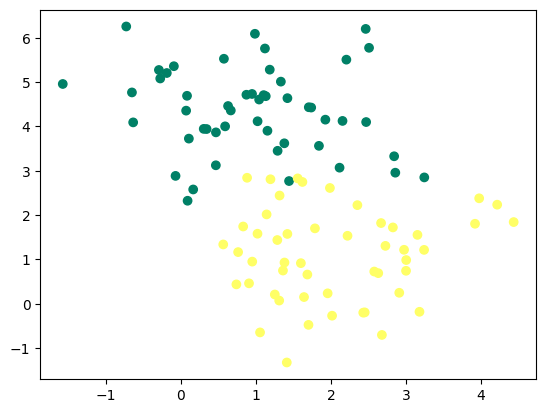

In [34]:
X, y =make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape(y.shape[0], 1)
print('dimension de X', X.shape)
print('dimension de Y', y.shape)

plt.scatter(X[:, 0], X[:,1], c=y, cmap='summer')

In [35]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [36]:
def model(X, W, b): 
    Z = X.dot(W) + b
    A = 1 / (1 + np.exp(-np.clip(Z, -500, 500)))
    return A 

In [37]:
def log_loss(A, y):
    A = np.clip(A, 1e-15, 1 - 1e-15)
    return 1/ len(y) * np.sum(-y * np.log(A) - (1-y) * np.log(1 - A))

In [38]:
def gradients (A, X, y) : 
    dW = 1 / len(y) * np.dot(X.T, A-y) 
    db = 1/ len(y) * np.sum(A-y)
    return (dW, db)

In [39]:
def update(dW, db, W, b, learning_rate): 
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

In [40]:
def predict(X , W, b): 
    A = model(X, W, b) 
    print(A)
    return A >= 0.5

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 100): 
    # initialisation W, b
    W, b = initialisation(X)

    Loss = []

    for i in range(n_iter): 
        A = model(X, W, b) 
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y) 
        W, b = update(dW, db, W, b, learning_rate)
    
    y_pred = predict(X , W, b) 
    print(accuracy_score(y , y_pred))
    
    plt.plot(Loss)

    return (W, b)

[[0.96818172]
 [0.67007427]
 [0.00723418]
 [0.11885584]
 [0.95516046]
 [0.34351877]
 [0.08416168]
 [0.95152337]
 [0.05494259]
 [0.79845119]
 [0.03913598]
 [0.82329115]
 [0.03882056]
 [0.02121814]
 [0.67821556]
 [0.98283272]
 [0.98549068]
 [0.04058815]
 [0.62523183]
 [0.58177905]
 [0.06023647]
 [0.04457757]
 [0.37263   ]
 [0.00726247]
 [0.9329274 ]
 [0.04270006]
 [0.82833773]
 [0.01502853]
 [0.08831883]
 [0.73360994]
 [0.96323065]
 [0.05761919]
 [0.58167239]
 [0.96392187]
 [0.40155589]
 [0.28321024]
 [0.71171217]
 [0.54883572]
 [0.48903235]
 [0.374253  ]
 [0.06247073]
 [0.12634185]
 [0.00143003]
 [0.1847199 ]
 [0.19203557]
 [0.8109349 ]
 [0.94208189]
 [0.9286162 ]
 [0.00587874]
 [0.01451709]
 [0.90593627]
 [0.47386497]
 [0.08552239]
 [0.05851341]
 [0.83373564]
 [0.05706902]
 [0.73456772]
 [0.76840767]
 [0.93771735]
 [0.98259001]
 [0.594296  ]
 [0.22276625]
 [0.00716077]
 [0.90983991]
 [0.02375568]
 [0.36552135]
 [0.03824368]
 [0.66131692]
 [0.93366876]
 [0.30230336]
 [0.19000577]
 [0.87

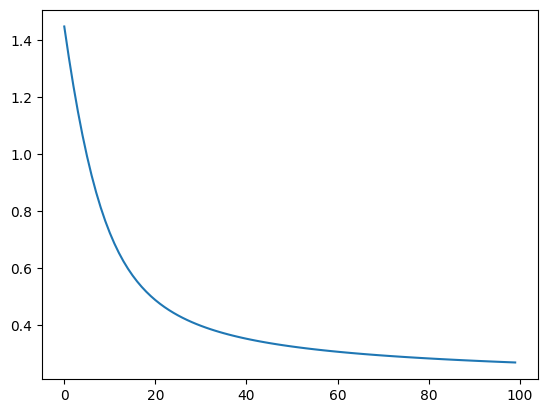

In [43]:
W, b = artificial_neuron(X, y)

[0.83775301]


array([ True])

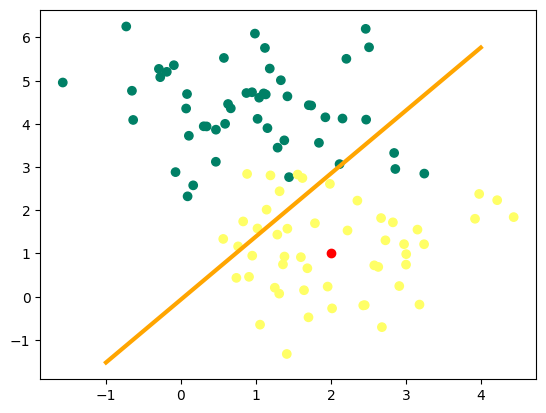

In [44]:
new_plant = np.array([2, 1]) 

x0 = np.linspace(-1, 4, 100) 
x1 = (-W[0] * x0 - b) / W[1]
plt.plot(x0, x1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.scatter(new_plant[0], new_plant[1], c='r')
plt.plot(x0, x1, c='orange', lw=3)
predict(new_plant, W, b)

## Animation

In [45]:
import plotly.graph_objects as go

In [46]:
fig = go.Figure(data=[go.Scatter3d(
    x=X[:, 0].flatten(),
    y=X[:, 1].flatten(),
    z=y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity=0.8,
        reversescale=True
    )
)])

fig.update_layout(template='plotly_dark', margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()


In [47]:
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx0, xx1 = np.meshgrid(X0, X1)
Z = W[0] * xx0 + W[1] * xx1 + b
A = 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

fig = (go.Figure(data=[go.Surface(z=A, x=xx0, y=xx1, colorscale='YlGn', opacity = 0.7, reversescale=True)]))

fig.add_scatter3d(x=X[:, 0].flatten(), y=X[:, 1].flatten(), z=y.flatten(), mode='markers', marker=dict(size=5, color=y.flatten(), colorscale='YlGn', opacity = 0.9, reversescale=True))


fig.update_layout(template= "plotly_dark", margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()


In [48]:
import numpy as np
import plotly.graph_objects as go

# Grille sur l'espace des features
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 120)
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 120)
xx0, xx1 = np.meshgrid(X0, X1)

# Securise la forme de W
w0, w1 = W.flatten()[:2]

# Logit + sigmoide
Z = w0 * xx0 + w1 * xx1 + b
A = 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

fig = go.Figure()

# Surface de probabilite P(y=1|x)
fig.add_trace(go.Surface(
    x=xx0, y=xx1, z=A,
    colorscale="YlGn",
    opacity=0.70,
    reversescale=True,
    showscale=True,
    name="P(y=1|x)"
))

# Frontiere de decision A=0.5
fig.add_trace(go.Contour(
    x=X0, y=X1, z=A,
    contours=dict(start=0.5, end=0.5, size=1, coloring="lines"),
    line=dict(color="red", width=4),
    showscale=False,
    name="Frontiere A=0.5"
))

# Points reels (z = y in {0,1})
fig.add_trace(go.Scatter3d(
    x=X[:, 0].flatten(),
    y=X[:, 1].flatten(),
    z=y.flatten(),
    mode="markers",
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale="YlGn",
        opacity=0.9,
        reversescale=True
    ),
    name="Data"
))

fig.update_layout(
    template="plotly_dark",
    margin=dict(l=0, r=0, b=0, t=0),
    scene=dict(
        xaxis_title="x0",
        yaxis_title="x1",
        zaxis_title="prob / label",
    )
)

fig.layout.scene.camera.projection.type = "orthographic"
fig.show()



## Exercice - Cat vs Dogs

In [49]:
from utilities import *

In [50]:
X_train, y_train, X_test, y_test = load_data()

In [51]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train, return_counts=True))

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [52]:
print(X_test.shape)
print(y_test.shape)
print(np.unique(y_test, return_counts=True))

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


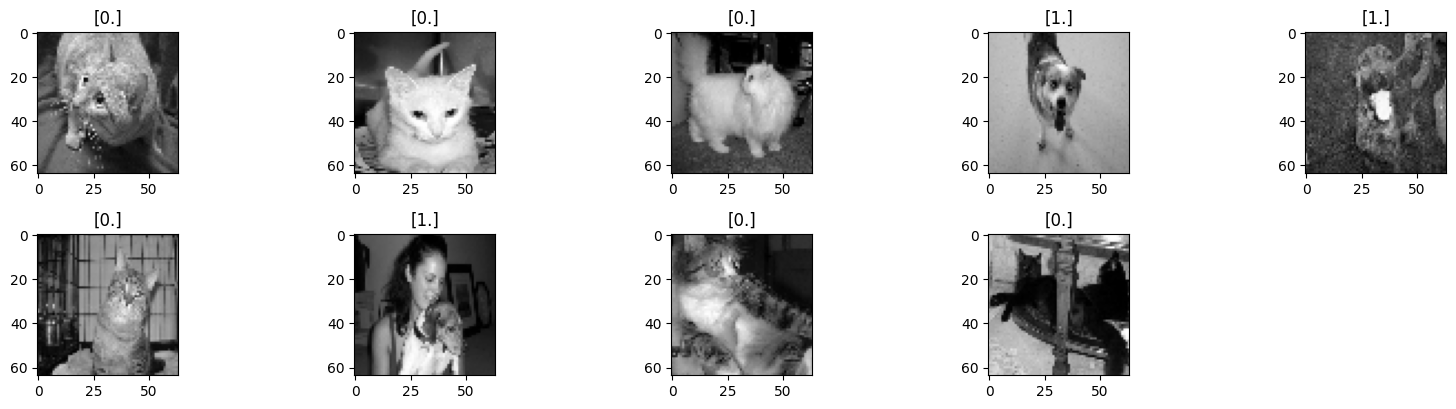

In [53]:
plt.figure(figsize=(16, 8)) 
for i in range(1, 10): 
    plt.subplot(4, 5, i) 
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.tight_layout()

## Nicolas's version

In [54]:
X_train_reshape = X_train.reshape(X_train.shape[0], -1)
X_train_reshape.shape

(1000, 4096)

In [55]:
X_test_reshape = X_test.reshape(X_test.shape[0], -1)
X_test_reshape.shape

(200, 4096)

In [56]:
def log_loss(A, y, epsilon):
    epsilon = 1e-15
    return 1/ len(y) * np.sum(-y * np.log(A + epsilon) - (1-y) * np.log(1 - A + epsilon))

In [57]:
W, b = artificial_neuron(X_train_reshape, y_train)

/var/folders/gg/dm5j6jg565j0bblwgpt9ggsw0000gn/T/ipykernel_735/2798717134.py:3: RuntimeWarning:

overflow encountered in exp



TypeError: log_loss() missing 1 required positional argument: 'epsilon'